# Lossless Preparation of Multi-Frequency Signal by DFT

This example corresponds to a special case in which the signal possesses an exactly sparse Fourier representation. Consequently, no thresholding is required and the reconstruction remains lossless.

## Imports

In [2]:
import sys
sys.path.append("../src")

In [3]:
import numpy as np
import matplotlib.pyplot as plt

from hybridqsp.transforms import dft, idft

from hybridqsp.thresholding import (
    top_k_threshold,
    magnitude_threshold
)

from hybridqsp.metrics import (
    state_fidelity,
    trace_distance
)

## Signal Generation
We construct a synthetic signal composed of multiple sinusoidal components in order to study sparse Fourier representations.

In [4]:
n = 8  # Number of qubits
srate = 2**n  # sampling rate Hz

# time interval
t = np.arange(0. , 1. ,1/srate)

x1 = 5 * np.sin(2 * np.pi *3* t) # First sinewave
x2 = 7 * np.cos(2 * np.pi * 20 * t) # Third sinewave


x =  x1 + x2
target_f =  x/np.linalg.norm(x)

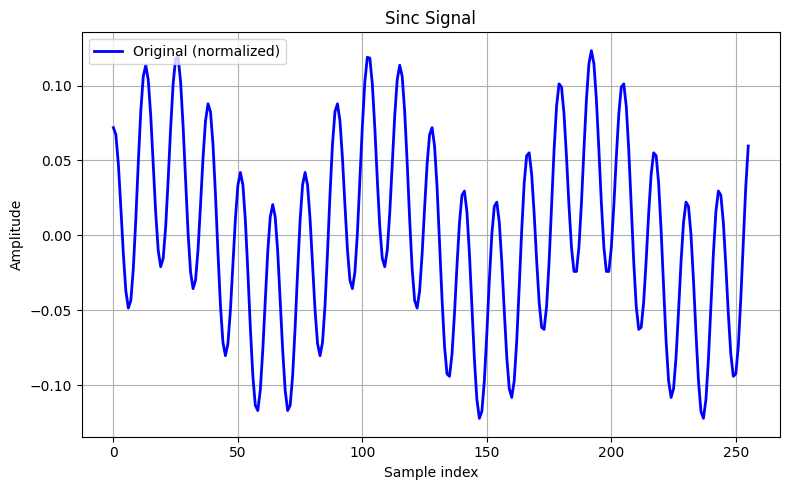

In [5]:
plt.figure(figsize=(8, 5))
plt.plot(target_f, label="Original (normalized)", lw=2, color="blue")

plt.title(f"Sinc Signal")
plt.xlabel("Sample index");
plt.ylabel("Amplitude")
plt.grid(True);
plt.legend();
plt.tight_layout();
plt.show()

## Fourier Transform
The signal is transformed into the frequency domain using the unitary Discrete Fourier Transform (DFT).

In [6]:
X = dft(x)

In [7]:
freqs = np.fft.fftfreq(len(X), d=1/srate)

### Visualization of Frequency Domain

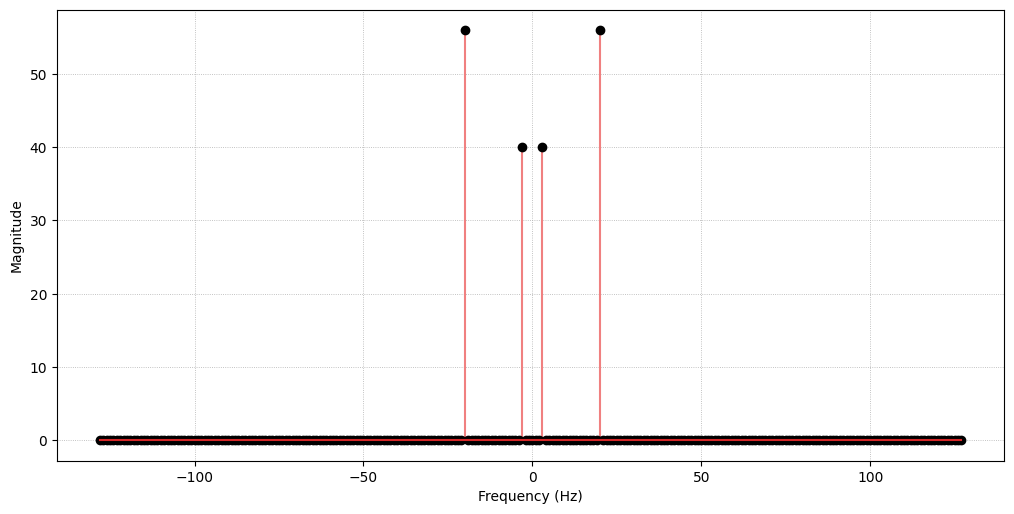

In [8]:
plt.figure(figsize=(10,5))  # smaller height for paper

# Plot original 
plt.stem(freqs, np.abs(X), linefmt="lightcoral", markerfmt="ko")
# Labels and grid
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.grid(True, linestyle=':', linewidth=0.6)

# Tidy up layout
plt.tight_layout(pad=0.2)
plt.show()

## Normalization
Due to floating-point numerical precision, the Fourier representation contains negligible coefficients with magnitudes close to machine precision. These coefficients are removed using a numerical tolerance in order to recover the exact sparse structure of the signal.

In [9]:
tol = 1e-10

X_clean = X.copy()

X_clean[np.abs(X_clean) < tol] = 0

In [10]:
X_norm = X_clean/np.linalg.norm(X_clean)

# Checking the normalization of x_norm
np.linalg.norm(X_norm)

np.float64(1.0)

## Classical Signal Reconstruction

In [11]:
x_rec = idft(X_norm).real

In [12]:
x_norm = x/np.linalg.norm(x)

## Reconstruction Metrics

In [13]:
F = state_fidelity(x_norm, x_rec)

D = trace_distance(x_norm, x_rec)

In [14]:
print("state fidelity=", F, "        Trace Distance=", D)

state fidelity= 1.0         Trace Distance= 0.0


## Visualization

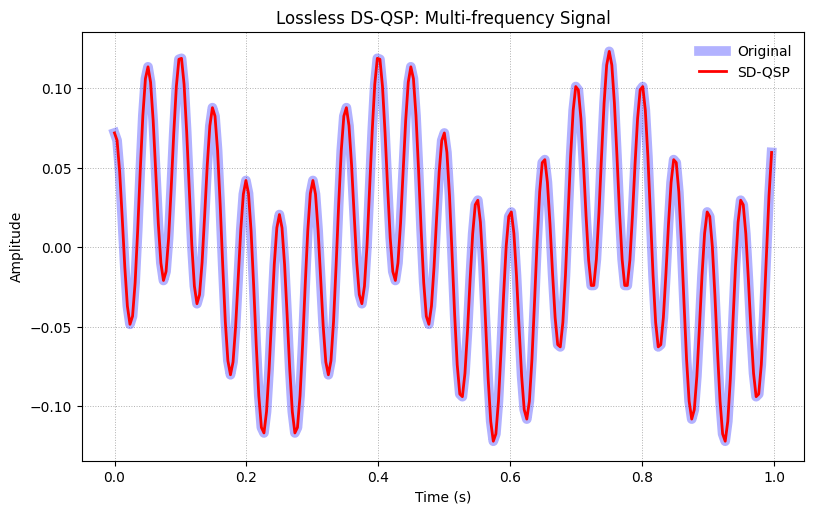

In [15]:
# Your existing time and signals
plt.figure(figsize=(8,5))  # smaller height for paper

# Plot original (thicker)
plt.plot(t, x_norm, label="Original", color='blue', lw=7, alpha=0.3)

# Plot reconstructed (dashed, slightly thinner)
plt.plot(t, x_rec, label="SD-QSP", linewidth=2, color="red")
plt.title("Lossless DS-QSP: Multi-frequency Signal")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(True, linestyle=':', linewidth=0.7)

# Add legend (best location based on content)
plt.legend(loc='upper right', frameon=False)

# Tidy up layout
plt.tight_layout(pad=0.2)

# Optional save for LaTeX
plt.savefig("../figures/Multi-Periodic_signal_preparation.pdf")

plt.show()

## Quantum Reconstruction via the Inverse Quantum Fourier Transform}

In [16]:
from qibo import Circuit, gates
from qibo.models import QFT
from qibo.models.encodings import sparse_encoder
from qibo.ui import plot_circuit

In [17]:
# Parameters
A = 0.4109974683
B = 0.5753964556
theta = np.arccos(np.sqrt(2)*A)  # such that cosθ = sqrt(2) A, sinθ = sqrt(2) B

In [45]:
from qibo import Circuit, gates

qc = Circuit(8)

qc.add(gates.H(0))

qc.add(gates.RY(3, 2 * theta))

qc.add(gates.CNOT(3, 5))
qc.add(gates.CNOT(0, 4))

qc.add(gates.CNOT(0, 1))
qc.add(gates.CNOT(0, 2))
qc.add(gates.CNOT(0, 3))

qc.add(gates.TOFFOLI(3, 4, 7))

qc.add(gates.SDG(7))

qc.add(gates.CNOT(7, 5))

qc.add(gates.X(5))
qc.add(gates.CNOT(5, 7))
qc.add(gates.CNOT(5, 6))
qc.add(gates.X(5))

qc.add(gates.S(6))


# ------------------------------------------------
# inverse QFT
# ------------------------------------------------
iqft = QFT(nqubits=n).invert()
qc.add(iqft.on_qubits(0,1,2,3,4,5,6,7))


print(qc.decompose().decompose().summary())

Circuit depth = 74
Total number of gates = 189
Number of qubits = 8
Most common gates:
rz: 84
cx: 82
h: 11
t: 4
tdg: 3
x: 2
ry: 1
sdg: 1
s: 1
None


(<Axes: >, <Figure size 3180x480 with 1 Axes>)

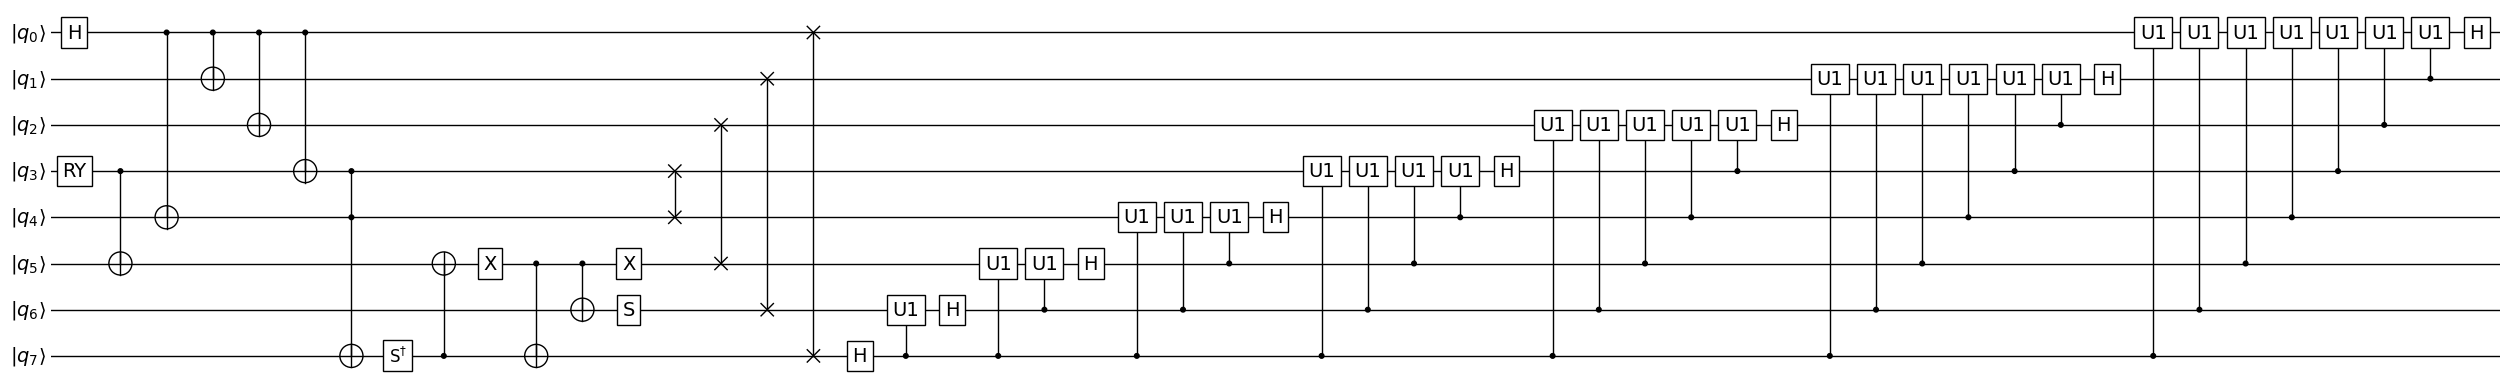

In [46]:
plot_circuit(qc)

### Statevector of the Quantum SQSP and Quantum Decompression

In [47]:
result = qc()

state = result.state()

In [48]:
td = trace_distance(target_f, state)

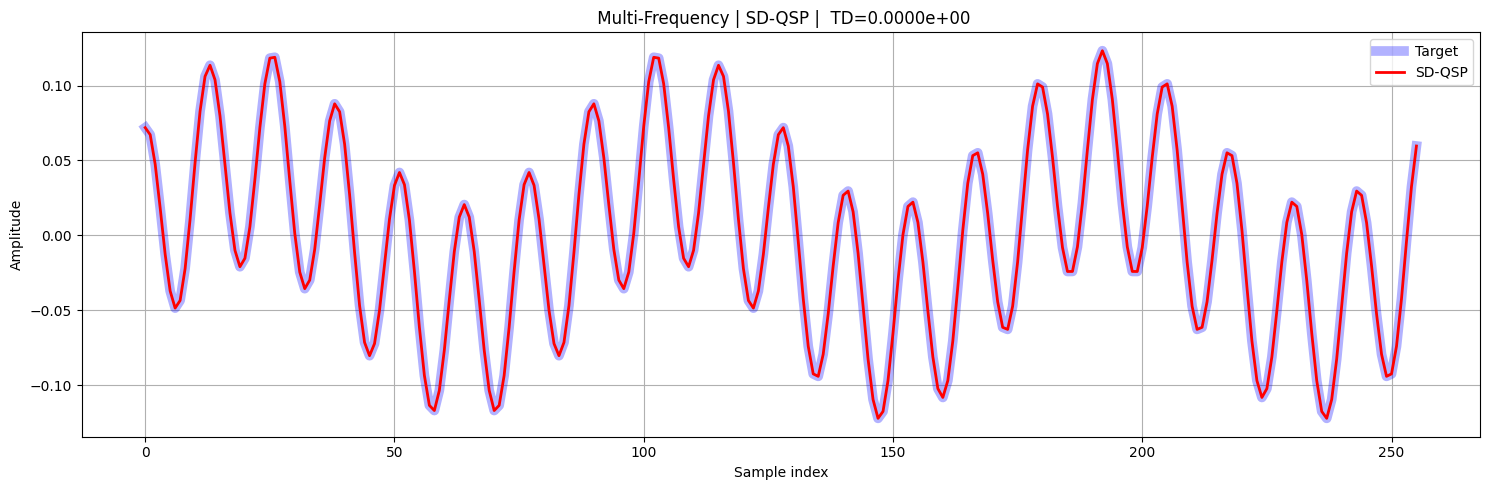

In [51]:
plt.figure(figsize=(15, 5))
plt.plot(target_f, 'blue', lw=7, alpha=0.3, label="Target")
plt.plot(state.real, lw=2, color="red", label="SD-QSP")
plt.title(f" Multi-Frequency | SD-QSP |  TD={td:.4e}")
plt.xlabel("Sample index");
plt.ylabel("Amplitude")
plt.grid(True);
plt.legend();
plt.tight_layout();
plt.show()